# 8. SCE Enrichment — Statistical Context Engineering (FOC-177, phase F2)

The F2 question: **does leakage-safe statistical context enrichment (SCE) beat the
dictionary signal on this fraud problem?**

Reference ladder established by the earlier phases (docs/FOC-174-report.md §2.5):

- **F0** — the evaluation harness (nb6) and the XGB baseline on the 10
  transaction features: test PR-AUC 0.0532 on the chronological split
  (re-established in nb7 arm a).
- **F1** — synthetic client enrichment (nb7): base + 8 `dim_customer` columns
  lifts test PR-AUC 0.0532 -> 0.2374 on the chronological split — read there as
  customer-identity signal, not transferable demographics.
- **nb4** — dictionary-based rule model, test PR-AUC 0.329 (stratified split).
- **nb5** — combined model (dictionary scores + base features -> XGB), test
  PR-AUC 0.507 (stratified split).

Method: SCE (package `sce` 0.4.0, `StatisticalContextEngine`) augments every row
with fraud-rate statistics of the groups it belongs to — one group per
categorical column plus every 2-way interaction — computed **out-of-fold by
time**, so a row's context features never see its own or any later target.

Four arms under two splits (8 result rows):

- **(a) base** — the 10 transaction features (the nb3/nb7 arm-a set);
- **(b) base + client** — nb7 arm-b reproduction (8 raw `dim_customer` columns);
- **(c) base + SCE** — the base features enriched with SCE fraud-rate context
  features (engine refit inside every CV fold);
- **(d) base + dictionary** — nb5-style dictionary scores as features
  (dictionaries and thresholds built on the fitting rows only).

Every arm runs under the chronological split AND the customer-grouped split,
under nb7's protocol: identical rows per split (asserted), validation carve from
TRAIN only, frozen threshold, one-shot test evaluation.

In [1]:
# Runtime provenance - executed in the phase worktree venv built from the
# pinned requirements (kernel python3). Printed so the committed, executed
# notebook self-documents the exact runtime the numbers were produced on.
import platform
import sys

import numpy
import pandas
import sce
import sklearn
import xgboost

print("python:", sys.version.split()[0], "| platform:", platform.platform())
print("kernel:", "python3 (nbclient + WindowsSelectorEventLoopPolicy)")
for _mod in (pandas, numpy, sklearn, xgboost, sce):
    print("%s: %s" % (_mod.__name__, _mod.__version__))

python: 3.11.9 | platform: Windows-10-10.0.26200-SP0
kernel: python3 (nbclient + WindowsSelectorEventLoopPolicy)
pandas: 2.3.3
numpy: 2.4.6
sklearn: 1.7.2
xgboost: 2.1.4
sce: 0.4.0


In [2]:
import io
import itertools
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from sce import AggregationMethod, ContextConfig, StatisticalContextEngine

from funs import (
    chronological_split,
    createDictionary,
    createMetaDictionary,
    cross_validate_model,
    dataPreparation,
    dictionaryModel,
    evaluateModel,
    grouped_split,
)

## Data load and client join

Mirrors nb7: `dataPreparation()` merged (validated `many_to_one`) with the
synthetic `dim_customer` table, plus two binned client columns (`age_band`,
`tenure_band`) so the numeric client attributes can serve as SCE grouping keys.

In [3]:
trxns = dataPreparation(
    all_trxns_path="../data/all_trxns.csv",
    exchange_rates_path="../data/exchange_rates.csv",
)
dim_customer = pd.read_csv("../data/dim_customer.csv")

enriched = trxns.merge(dim_customer, on="customer", how="left", validate="many_to_one")

assert len(enriched) == len(trxns), "join lost rows"
client_cols = [c for c in dim_customer.columns if c != "customer"]
assert int(enriched[client_cols].isna().sum().sum()) == 0, "join introduced nulls"

# SCE groups on categories, so the two numeric client attributes enter the
# grouping set as binned versions. Edges chosen so no bin is empty on this
# table (age spans 18-82, tenure 0-25 years).
enriched["age_band"] = pd.cut(
    enriched["age"],
    bins=[17, 25, 40, 55, 120],
    labels=["18-25", "26-40", "41-55", "56+"],
)
enriched["tenure_band"] = pd.cut(
    enriched["account_tenure_years"],
    bins=[-1, 2, 7, 15, 100],
    labels=["0-2", "3-7", "8-15", "16+"],
)
assert enriched["age_band"].notna().all(), "age binning produced NaN"
assert enriched["tenure_band"].notna().all(), "tenure binning produced NaN"

BASE_FEATURES = [
    "customer_country",
    "counterparty_country",
    "type",
    "ccy",
    "customer_type",
    "weekday",
    "month",
    "quarter",
    "hour",
    "amount_eur_bucket",
]
CLIENT_NUMERIC = ["age", "account_tenure_years"]
CLIENT_CATEGORICAL = [
    "gender",
    "employment_industry",
    "employment_status",
    "income_band",
    "device",
    "channel",
]
# SCE grouping candidates: the 10 transaction categoricals + the 6 categorical
# client attributes + the 2 binned client numerics. The customer id itself is
# deliberately excluded - a per-customer fraud rate would re-import the
# identity signal nb7 measured and could not transfer to unseen customers.
GROUPING_COLS = BASE_FEATURES + CLIENT_CATEGORICAL + ["age_band", "tenure_band"]
missing = [c for c in GROUPING_COLS if c not in enriched.columns]
assert not missing, "planned grouping columns absent from the prepared frame: %s" % missing

y_full = enriched["fraud_flag"].map({"N": 0, "Y": 1})
assert y_full.notna().all(), "unexpected fraud_flag label outside {N, Y}"
y_full = y_full.astype(int)

print(
    "fraud txns: %d of %d (%.2f%%) across %d unique customers"
    % (int(y_full.sum()), len(y_full), 100 * y_full.mean(), enriched["customer"].nunique())
)
print("grouping columns (%d):" % len(GROUPING_COLS))
print(enriched[GROUPING_COLS].nunique().to_string())

fraud txns: 91 of 5302 (1.72%) across 100 unique customers
grouping columns (18):
customer_country         3
counterparty_country    11
type                     8
ccy                      9
customer_type            4
weekday                  7
month                   12
quarter                  4
hour                    24
amount_eur_bucket        5
gender                   2
employment_industry      8
employment_status        5
income_band              5
device                   3
channel                  4
age_band                 4
tenure_band              4


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:197: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  trxns_data["timestamp"] = pd.to_datetime(


## SCE method — fraud-rate context features

For every grouping column `c` the engine computes the group's fraud statistics
(`{c}_fraud_mean`, `{c}_fraud_count`) and joins them onto each row; with
`include_interactions=True` it does the same for every 2-way column pair
(`{c1}__{c2}_fraud_mean`, ...). Global rates (`global_fraud_mean`,
`global_fraud_count`) are broadcast to all rows. The engine does NOT encode raw
string columns for the estimator (its own pipeline docs) — categoricals are
one-hot encoded for XGBoost, while the raw grouping columns are kept for SCE.

**Cross-fit strategy: `"time"` (strictly past-only, verified against the
installed source).** `engine.py` sorts the rows by `time_col`, runs
`TimeSeriesSplit(n_folds)`, and for each fold computes the group statistics from
the fold-train rows only (`train_df = X_cf.iloc[train_idx]`), then joins them
onto that fold's validation rows. A `TimeSeriesSplit` train block always ends
where the validation block begins, so **every row's statistics come exclusively
from rows strictly earlier than itself** — past-only at row level, not merely at
fold level. Cell below verifies this empirically by flipping future targets.
`"rolling"` was therefore unnecessary: it only additionally caps the window
size. After the cross-fit loop the engine refits its statistics on the full
training frame, so `.transform()` enriches out-of-sample rows from
training-period statistics only.

**Grouping columns (18):** `customer_country`, `counterparty_country`, `type`,
`ccy`, `customer_type`, `weekday`, `month`, `quarter`, `hour`,
`amount_eur_bucket` (all produced by `dataPreparation`) + `gender`,
`employment_industry`, `employment_status`, `income_band`, `device`, `channel`
(from `dim_customer`) + `age_band` (edges `[17, 25, 40, 55, 120]`) and
`tenure_band` (edges `[-1, 2, 7, 15, 100]`). All exist in the prepared frame —
asserted at load. `customer` is excluded on purpose (see the load cell). With
`include_interactions=True` this yields 18 single-column levels + 153 pair
levels + the global level = 172 hierarchy levels, 2 statistics each (MEAN,
COUNT) = 344 context columns on top of the base features.

**`min_group_size=5`:** groups with fewer than 5 rows are dropped from the
statistics and their rows back off to a coarser level / the global rate. With
91 positives (1.72%), a 2-3 row group turns a single fraud into a 33-50% "fraud
rate" — pure noise; 5 is the smallest size that keeps transaction-level groups
alive without that pathology.

**`n_folds=5`:** `TimeSeriesSplit` over ~4.2k chronological train rows yields 5
out-of-fold blocks of ~700 rows each — large enough for stable group rates —
and matches the `k=5` of `cross_validate_model`, so both CV layers use the same
fold count.

**Aggregations trimmed to MEAN + COUNT.** For a 0/1 target the library's other
default aggregations (median, std, quantiles) are deterministic functions of
the group mean, so they would multiply columns without adding signal. MEAN is
the group fraud rate, COUNT the group support.

**`include_relative_features=False`** — the library documents these features as
direct target leakage (they use the row's own y).

**Known artifact:** the time strategy covers only the last
`n_folds / (n_folds + 1)` (~83%) of rows with out-of-fold statistics; the
earliest ~17% of training rows keep NaN context features (the engine falls back
to the raw row there). XGBoost routes NaN natively, and test rows always
receive full features from `.transform()`, but the train/test feature
availability differs — carried into the interpretation caveats.

**Unseen groups at transform:** a left join leaves NaN for groups that never
occurred in training, and `apply_hierarchical_backoff` fills those from
progressively coarser levels down to the global rate — transform() never errors
on unseen groups. Verified empirically below.

In [4]:
SCE_CONFIG = ContextConfig(
    target_col="fraud",
    categorical_cols=GROUPING_COLS,
    aggregations=[AggregationMethod.MEAN, AggregationMethod.COUNT],
    min_group_size=5,
    use_cross_fitting=True,
    cross_fit_strategy="time",
    time_col="timestamp",
    n_folds=5,
    random_state=42,  # unused by the deterministic time strategy; kept explicit
    include_interactions=True,
    include_global_stats=True,
    include_relative_features=False,  # library WARNING: target leakage
    include_fold_variance=False,      # fold-variance features only exist for the random strategy
    add_backoff_depth=False,
)
print("SCE_CONFIG ready: %d grouping columns, strategy=%s, n_folds=%d"
      % (len(GROUPING_COLS), SCE_CONFIG.cross_fit_strategy, SCE_CONFIG.n_folds))

SCE_CONFIG ready: 18 grouping columns, strategy=time, n_folds=5


## Leakage verification — does `"time"` cross-fitting actually mean past-only?

Two empirical checks against the production config, on a throwaway engine
(no comparison result depends on it):

1. **Past-only check.** All targets strictly after the 60th-percentile
   timestamp are truncated to 0 and the engine is re-run. Every row at or
   before the cut must keep identical context features — its statistics window
   only reaches rows strictly earlier than itself, all of which are before the
   cut. As a control, rows AFTER the cut must move; otherwise the check would
   be vacuous (features ignoring targets entirely). The cut sits at the 60th
   (not 75th) percentile so the flip zone overlaps the rows that actually feed
   fold statistics: with `n_folds` time folds, the last `1/(n_folds+1)` of rows
   only ever appear inside validation blocks and never contribute statistics —
   a cut deeper than `n_folds/(n_folds+1)` could not move any feature at all.
2. **Unseen groups.** The engine is fit on the frame and transforms a copy in
   which `ccy` is replaced by a level that never occurs in training.
   `transform()` must not error and must back off to the global rate.

In [5]:
verif_frame = enriched[GROUPING_COLS + ["timestamp"]]
verif_y = y_full

cut_time = verif_frame["timestamp"].quantile(0.60)
future_mask = verif_frame["timestamp"] > cut_time
print(
    "cut at %s — %d of %d rows after the cut (%d of %d frauds truncated to 0)"
    % (
        cut_time,
        int(future_mask.sum()),
        len(future_mask),
        int(verif_y[future_mask].sum()),
        int(verif_y.sum()),
    )
)

ctx_reference = StatisticalContextEngine(SCE_CONFIG).fit_transform(verif_frame, verif_y)
ctx_truncated = StatisticalContextEngine(SCE_CONFIG).fit_transform(
    verif_frame, verif_y.mask(future_mask, 0)
)

stat_cols = [c for c in ctx_reference.columns if c not in verif_frame.columns]
covered = ctx_reference[stat_cols].notna().any(axis=1)  # excludes the NaN OOF head

# Rows at or before the cut: features must be identical under both targets.
past_diff = (
    ctx_reference.loc[covered & ~future_mask, stat_cols]
    - ctx_truncated.loc[covered & ~future_mask, stat_cols]
).abs().to_numpy()
assert float(np.nanmax(past_diff)) <= 1e-12, (
    "leakage: rows before the cut changed their SCE features when future "
    "targets were truncated"
)
print(
    "past-only check: PASS — %d rows before the cut unchanged (max diff %.1e)"
    % (int((covered & ~future_mask).sum()), float(np.nanmax(past_diff)))
)

# Control: features must react to targets somewhere, or the check is vacuous.
future_diff = (
    ctx_reference.loc[covered & future_mask, stat_cols]
    - ctx_truncated.loc[covered & future_mask, stat_cols]
).abs().to_numpy()
assert float(np.nanmax(future_diff)) > 1e-9, (
    "vacuous check: SCE features do not respond to targets at all"
)
print(
    "control: PASS — rows after the cut moved (max diff %.4f)"
    % float(np.nanmax(future_diff))
)

# Unseen group at transform time: must back off to the global rate, not error.
unseen_frame = verif_frame.copy()
unseen_frame["ccy"] = "ZZ_unseen"
fitted_engine = StatisticalContextEngine(SCE_CONFIG).fit(verif_frame, verif_y)
ctx_unseen = fitted_engine.transform(unseen_frame)

unseen_rate = ctx_unseen["ccy_fraud_mean"]
global_rate = ctx_unseen["global_fraud_mean"]
assert np.allclose(unseen_rate, global_rate), (
    "unseen group did not back off to the global rate"
)
assert not ctx_unseen[stat_cols].isna().any().any(), (
    "backoff left NaN context features for unseen groups"
)
print(
    "unseen-group check: PASS — 'ZZ_unseen' ccy rate backs off to "
    "global_fraud_mean=%.4f (no NaN features, no error)"
    % float(global_rate.iloc[0])
)

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)


cut at 2021-08-09 08:41:53 — 2121 of 5302 rows after the cut (46 of 91 frauds truncated to 0)


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

...

past-only check: PASS — 2294 rows before the cut unchanged (max diff 0.0e+00)
control: PASS — rows after the cut moved (max diff 0.2857)
  SCE using 18 categorical columns: ['customer_country', 'counterparty_country', 'type', 'ccy', 'customer_type', 'weekday', 'month', 'quarter', 'hour', 'amount_eur_bucket', 'gender', 'employment_industry', 'employment_status', 'income_band', 'device', 'channel', 'age_band', 'tenure_band']


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(group_cols, dropna=False)
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sce\stats.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

unseen-group check: PASS — 'ZZ_unseen' ccy rate backs off to global_fraud_mean=0.0172 (no NaN features, no error)


## 4 arms x 2 splits — comparison protocol

Identical to nb7's A/B discipline, extended to four arms:

- **One split per split-name, computed once on row indices** — chronological
  (`chronological_split`, last `ceil(0.2 * 5302)` rows) and customer-grouped
  (`grouped_split`, last `ceil(0.2 * 100)` customers by first-seen
  transaction). Every arm must consume exactly those rows (asserted).
- **Validation carve:** 25% of TRAIN, stratified, seed 42 — from the training
  side only, so the threshold never sees test.
- **XGB hyperparameters:** nb7's fixed set, identical for every arm and split;
  `scale_pos_weight` = neg/pos of the fitting carve.
- **CV:** stratified 5-fold on TRAIN via `cross_validate_model`. Arms (c) and
  (d) wrap their feature construction in a sklearn estimator whose `fit()`
  rebuilds the enrichment from the fitting rows — so each fold's validation
  rows are scored with statistics that never saw them (out-of-fold for SCE,
  out-of-fold dictionaries + threshold grid for the dictionary arm).
- **Threshold:** tuned for best F1 on the validation carve (the same
  computation as `evaluateModel`'s `best_threshold_f1`, without the plot side
  effects), then frozen and applied once to TEST.
- **Metrics:** test PR-AUC (primary), ROC-AUC, F1 at the frozen threshold,
  recall@precision 0.50, CV PR-AUC mean ± std, encoded feature count.

In [6]:
FIXED_XGB_PARAMS = dict(
    learning_rate=0.05,
    max_depth=6,
    n_estimators=200,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
)


def xgb_params(y_fit):
    # nb7 discipline: identical hyperparameters everywhere; the rare-class
    # weight is the neg/pos ratio of the fitting carve.
    params = dict(FIXED_XGB_PARAMS)
    params["scale_pos_weight"] = (y_fit == 0).sum() / (y_fit == 1).sum()
    return params


def best_f1_threshold(y_true, y_score):
    # Same computation as funs.evaluateModel's best_threshold_f1, without the
    # plot/print side effects (the validation tune does not need a figure).
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    if len(thresholds) == 0:
        return 0.5
    f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
    return float(thresholds[int(np.nanargmax(f1_scores[:-1]))])


def encode_dummies(frame, cat_cols):
    # One-hot encode; XGBoost forbids '[', ']' and '<' in feature names (the
    # income_band label '1_<20k' and interval buckets would inject them).
    X = pd.get_dummies(frame[cat_cols], columns=cat_cols)
    X.columns = [
        c.replace("[", "").replace("]", "").replace("<", "under") for c in X.columns
    ]
    return X


class SCERateEnricher(BaseEstimator):
    """XGB on base features + SCE fraud-rate context features.

    fit() runs engine.fit_transform on the fitting rows: with the production
    config (use_cross_fitting + strategy="time") every fitting row receives
    fraud-rate statistics built exclusively from strictly earlier rows. The
    engine also keeps full-fitting-frame statistics, so predict_proba()/
    predict() enrich out-of-sample rows through engine.transform(). Refitting
    inside fit() is what makes cross_validate_model honest for this arm: each
    fold's clone rebuilds the context features from its own fold-train rows.
    """

    def __init__(self, config, base_cols, model_params=None):
        self.config = config
        self.base_cols = base_cols
        self.model_params = model_params

    def fit(self, X, y):
        engine = StatisticalContextEngine(self.config)
        with redirect_stdout(io.StringIO()):  # engine prints a banner per fit
            enriched = engine.fit_transform(X, y)
        self.engine_ = engine
        self.raw_columns_ = list(X.columns)
        dummies = encode_dummies(enriched, self.base_cols)
        self.dummy_columns_ = dummies.columns.tolist()
        self.sce_columns_ = [
            c for c in enriched.columns if c not in self.raw_columns_
        ]
        matrix = pd.concat(
            [dummies, enriched.reindex(columns=self.sce_columns_)], axis=1
        )
        self.model_ = XGBClassifier(**self.model_params)
        self.model_.fit(matrix, np.asarray(y).ravel())
        return self

    def _enriched(self, X):
        with redirect_stdout(io.StringIO()):
            return self.engine_.transform(X)

    def _matrix(self, X):
        enriched = self._enriched(X)
        dummies = encode_dummies(enriched, self.base_cols).reindex(
            columns=self.dummy_columns_, fill_value=0
        )
        return pd.concat(
            [dummies, enriched.reindex(columns=self.sce_columns_)], axis=1
        )

    def predict_proba(self, X):
        return self.model_.predict_proba(self._matrix(X))

    def predict(self, X):
        return self.model_.predict(self._matrix(X))


DICT_VARS = list(BASE_FEATURES)
DICT_SCORE_COLS = [
    "expected_fraud_probability",
    "sd_flags",
    "quantile_flags",
    "quantile_1_flags",
    "quantile_25_flags",
    "quantile_75_flags",
    "quantile_9_flags",
]
DICT_FP_GRID = np.arange(0.05, 0.40, 0.025)
DICT_FLAG_GRID = [0, 1, 2, 3]


class DictionaryRateEnricher(BaseEstimator):
    """nb5-style dictionary features, rebuilt inside fit().

    Mirrors nb5: createDictionary + createMetaDictionary per dictionary
    variable (count_filter=0, nb5's choice) and the three-threshold F1 grid —
    ALL computed on the fitting rows only. dictionaryModel then scores any row
    set by looking up its group values; the scores never read the row's own
    target (dictionaryModel requires the fraud_flag column as input, but the
    label-derived columns are dropped and only the 7 aggregate scores become
    features). Wrapping nb5's construction keeps the CV folds and the
    validation carve out-of-sample — strictly cleaner than nb5's single
    stratified split, which fit dictionaries on the full training half.
    """

    def __init__(self, base_cols, dict_vars, model_params=None):
        self.base_cols = base_cols
        self.dict_vars = dict_vars
        self.model_params = model_params

    def fit(self, X, y):
        rows = X.copy()
        y_arr = np.asarray(y).ravel()
        self.dictionaries_ = {
            v: createDictionary(rows, colname=v, count_filter=0)
            for v in self.dict_vars
        }
        self.meta_dictionary_ = pd.concat(
            [
                createMetaDictionary(
                    rows, colname=v, quantile_threshold=0.9, count_filter=0
                )
                for v in self.dict_vars
            ],
            ignore_index=True,
        )
        # nb5's threshold grid on the fitting rows: the permissive call returns
        # the aggregation columns, the grid scans the three-threshold space.
        agg = dictionaryModel(rows, self.dictionaries_, self.meta_dictionary_, 0.0, -1, -1)
        best_f1, self.thresholds_ = -1.0, (0.2, 0, 0)
        for fp_t, sd_t, qf_t in itertools.product(
            DICT_FP_GRID, DICT_FLAG_GRID, DICT_FLAG_GRID
        ):
            pred = (
                (agg["expected_fraud_probability"] > fp_t)
                & (agg["sd_flags"] > sd_t)
                & (agg["quantile_flags"] > qf_t)
            ).astype(int)
            score = f1_score(y_arr, pred, zero_division=0)
            if score > best_f1:
                best_f1 = score
                self.thresholds_ = (float(fp_t), int(sd_t), int(qf_t))

        dummies = encode_dummies(rows, self.base_cols)
        self.dummy_columns_ = dummies.columns.tolist()
        matrix = pd.concat([dummies, self._dictionary_scores(rows)], axis=1)
        self.model_ = XGBClassifier(**self.model_params)
        self.model_.fit(matrix, y_arr)
        return self

    def _dictionary_scores(self, rows):
        out = dictionaryModel(rows, self.dictionaries_, self.meta_dictionary_, *self.thresholds_)
        assert len(out) == len(rows), "dictionaryModel changed the row count"
        scores = out[DICT_SCORE_COLS].reset_index(drop=True)
        scores.index = rows.index  # dictionaryModel preserves input row order
        return scores

    def _matrix(self, X):
        dummies = encode_dummies(X, self.base_cols).reindex(
            columns=self.dummy_columns_, fill_value=0
        )
        return pd.concat([dummies, self._dictionary_scores(X)], axis=1)

    def predict_proba(self, X):
        return self.model_.predict_proba(self._matrix(X))

    def predict(self, X):
        return self.model_.predict(self._matrix(X))


# Feature matrices and raw estimator inputs.
X_a_enc = encode_dummies(enriched, BASE_FEATURES)
X_b_enc = pd.concat(
    [encode_dummies(enriched, BASE_FEATURES + CLIENT_CATEGORICAL), enriched[CLIENT_NUMERIC]],
    axis=1,
)
# stat-context 0.4.0 quirk: its out-of-fold assignment string-casts
# converted-dtype grouping columns (int hour -> str hour, Interval bucket
# -> str bucket) while untouched rows keep the original values, so one
# column ends up holding mixed int/str values. That fragments the engine
# groups (24 hour groups become 48) and makes get_dummies emit duplicate
# dummy names downstream. Normalize the grouping columns to str at the
# boundary: groups stay exact, dummies stay unique. The timestamp column
# keeps its dtype - the time strategy needs it.
X_sce_raw = enriched[GROUPING_COLS + ["timestamp"]].copy()
X_sce_raw[GROUPING_COLS] = X_sce_raw[GROUPING_COLS].astype(str)
X_d_raw = enriched[DICT_VARS + ["customer", "counterparty", "timestamp", "fraud_flag"]]


def result_row(n_features, threshold, cv, test_metrics):
    return {
        "test PR-AUC": test_metrics["pr_auc"],
        "test ROC-AUC": test_metrics["roc_auc"],
        "test F1 (frozen threshold)": test_metrics["f1"],
        "test recall@precision=0.50": test_metrics["recall_at_precision"],
        "CV PR-AUC mean": cv["summary"]["pr_auc_mean"],
        "CV PR-AUC std": cv["summary"]["pr_auc_std"],
        "frozen threshold": threshold,
        "encoded features": n_features,
    }


def run_arm_features(X_enc, train_idx, test_idx):
    # nb7's run_arm pattern for the arms whose features are split-safe by
    # construction (plain one-hot matrices).
    X_tr, X_te = X_enc.loc[train_idx], X_enc.loc[test_idx]
    y_tr, y_te = y_full.loc[train_idx], y_full.loc[test_idx]
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_tr, y_tr, test_size=0.25, random_state=42, stratify=y_tr
    )
    model = XGBClassifier(**xgb_params(y_fit))
    cv = cross_validate_model(model, X_tr, y_tr, k=5, stratified=True, random_state=42)
    model.fit(X_fit, y_fit)
    threshold = best_f1_threshold(y_val, model.predict_proba(X_val)[:, 1])
    test_proba = model.predict_proba(X_te)[:, 1]
    test_metrics = evaluateModel(
        y_te, (test_proba >= threshold).astype(int), y_score=test_proba
    )
    return result_row(X_enc.shape[1], threshold, cv, test_metrics), train_idx, test_idx


def run_arm_enricher(make_enricher, X_raw, train_idx, test_idx):
    # Same protocol for the arms whose features are fitted objects. The
    # factory receives the fitting carve's y so the CV clones and the final
    # fit share one scale_pos_weight (nb7's behaviour); the enricher is then
    # refit inside every CV fold by cross_validate_model, and the final fit
    # sees only the validation-carved fitting rows.
    X_tr, X_te = X_raw.loc[train_idx], X_raw.loc[test_idx]
    y_tr, y_te = y_full.loc[train_idx], y_full.loc[test_idx]
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_tr, y_tr, test_size=0.25, random_state=42, stratify=y_tr
    )
    cv = cross_validate_model(
        make_enricher(y_fit), X_tr, y_tr, k=5, stratified=True, random_state=42
    )
    enricher = make_enricher(y_fit)
    enricher.fit(X_fit, y_fit)
    threshold = best_f1_threshold(y_val, enricher.predict_proba(X_val)[:, 1])
    test_proba = enricher.predict_proba(X_te)[:, 1]
    test_metrics = evaluateModel(
        y_te, (test_proba >= threshold).astype(int), y_score=test_proba
    )
    if isinstance(enricher, SCERateEnricher):
        n_features = len(enricher.dummy_columns_) + len(enricher.sce_columns_)
    else:
        n_features = len(enricher.dummy_columns_) + len(DICT_SCORE_COLS)
    return result_row(n_features, threshold, cv, test_metrics), train_idx, test_idx


def arm_a(train_idx, test_idx):
    return run_arm_features(X_a_enc, train_idx, test_idx)


def arm_b(train_idx, test_idx):
    return run_arm_features(X_b_enc, train_idx, test_idx)


def arm_c(train_idx, test_idx):
    return run_arm_enricher(
        lambda y_fit: SCERateEnricher(
            SCE_CONFIG, BASE_FEATURES, model_params=xgb_params(y_fit)
        ),
        X_sce_raw,
        train_idx,
        test_idx,
    )


def arm_d(train_idx, test_idx):
    return run_arm_enricher(
        lambda y_fit: DictionaryRateEnricher(
            BASE_FEATURES, DICT_VARS, model_params=xgb_params(y_fit)
        ),
        X_d_raw,
        train_idx,
        test_idx,
    )


ARMS = [
    ("a: base", arm_a),
    ("b: base + client", arm_b),
    ("c: base + SCE", arm_c),
    ("d: base + dictionary", arm_d),
]

chronological split: 4241 train / 1061 test rows | grouped split: 4471 train / 831 test rows, 80/20/100 customers (train/test/total)
chronological test positives: 24 of 1061 rows (chance PR-AUC 0.0226)
grouped test positives: 11 of 831 rows (chance PR-AUC 0.0132)


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

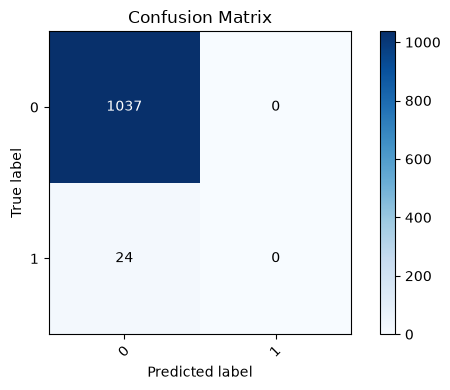


Accuracy: 97.74% 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1037
           1       0.00      0.00      0.00        24

    accuracy                           0.98      1061
   macro avg       0.49      0.50      0.49      1061
weighted avg       0.96      0.98      0.97      1061



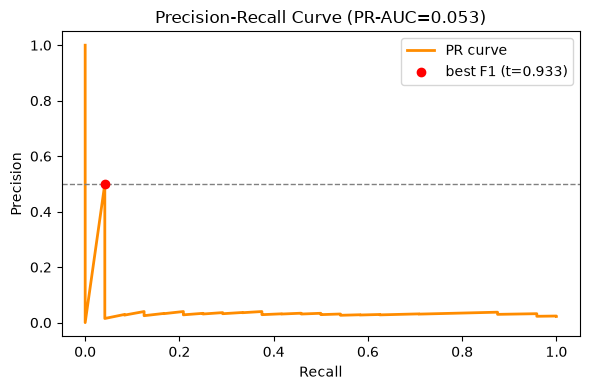

PR-AUC=0.0532  ROC-AUC=0.6361  F1=0.0000  Precision=0.0000  Recall=0.0000
Best F1 threshold=0.9329  Recall@precision=0.50=0.0417
[chronological | a: base] features=87 CV PR-AUC 0.4633+-0.0660 test PR-AUC 0.0532


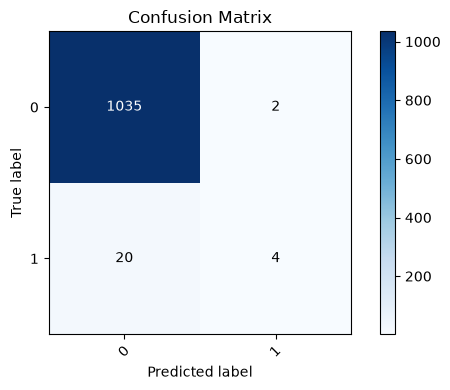


Accuracy: 97.93% 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1037
           1       0.67      0.17      0.27        24

    accuracy                           0.98      1061
   macro avg       0.82      0.58      0.63      1061
weighted avg       0.97      0.98      0.97      1061



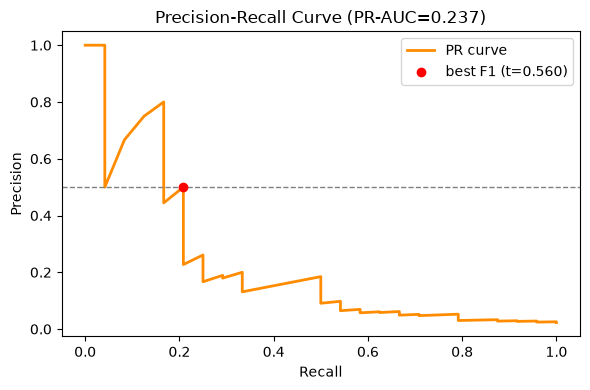

PR-AUC=0.2374  ROC-AUC=0.7692  F1=0.2667  Precision=0.6667  Recall=0.1667
Best F1 threshold=0.5600  Recall@precision=0.50=0.2083
[chronological | b: base + client] features=116 CV PR-AUC 0.5227+-0.0809 test PR-AUC 0.2374


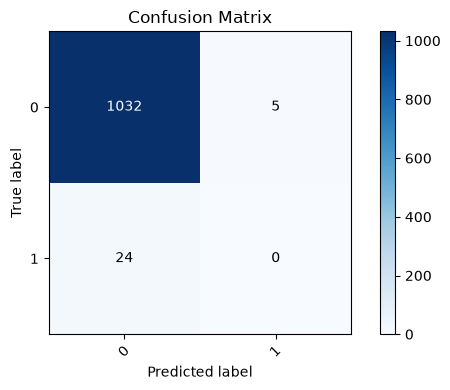


Accuracy: 97.27% 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1037
           1       0.00      0.00      0.00        24

    accuracy                           0.97      1061
   macro avg       0.49      0.50      0.49      1061
weighted avg       0.96      0.97      0.96      1061



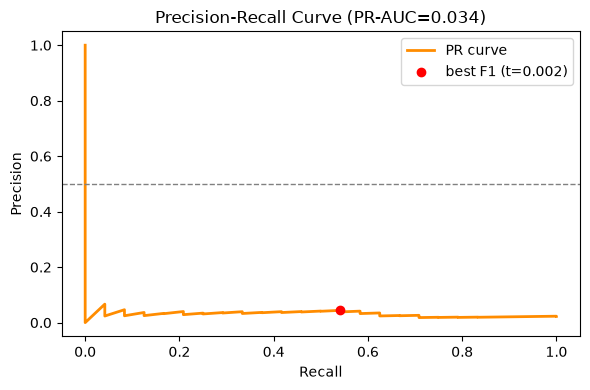

PR-AUC=0.0340  ROC-AUC=0.5542  F1=0.0000  Precision=0.0000  Recall=0.0000
Best F1 threshold=0.0022  Recall@precision=0.50=0.0000
[chronological | c: base + SCE] features=429 CV PR-AUC 0.2214+-0.1415 test PR-AUC 0.0340


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:270: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:276: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_group_names = count_group.groupby("value")["n"].count().reset_index(name="n_")
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:309: FutureWarning: The provided callable <function std at 0x000001D47F599260> is currently using SeriesGroupBy.std. In a

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:267: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:270: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:276: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

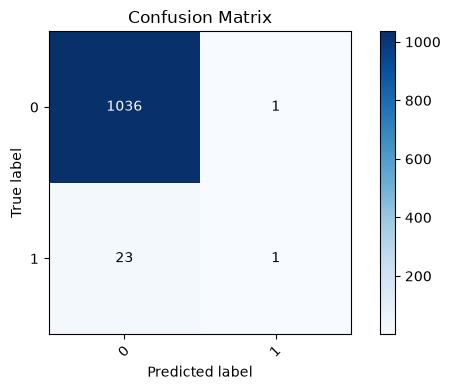


Accuracy: 97.74% 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1037
           1       0.50      0.04      0.08        24

    accuracy                           0.98      1061
   macro avg       0.74      0.52      0.53      1061
weighted avg       0.97      0.98      0.97      1061



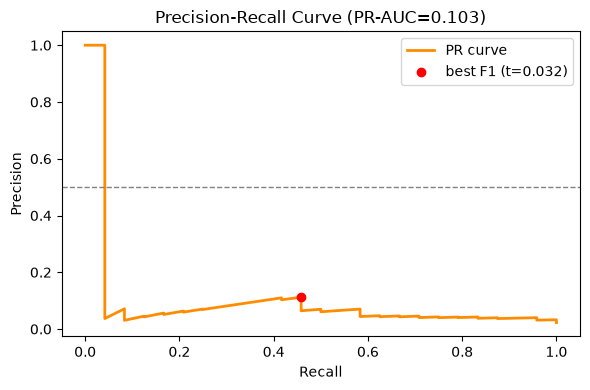

PR-AUC=0.1034  ROC-AUC=0.7653  F1=0.0769  Precision=0.5000  Recall=0.0417
Best F1 threshold=0.0325  Recall@precision=0.50=0.0417
[chronological | d: base + dictionary] features=92 CV PR-AUC 0.3539+-0.0814 test PR-AUC 0.1034


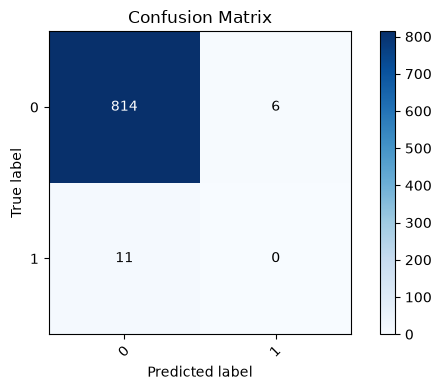


Accuracy: 97.95% 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       820
           1       0.00      0.00      0.00        11

    accuracy                           0.98       831
   macro avg       0.49      0.50      0.49       831
weighted avg       0.97      0.98      0.98       831



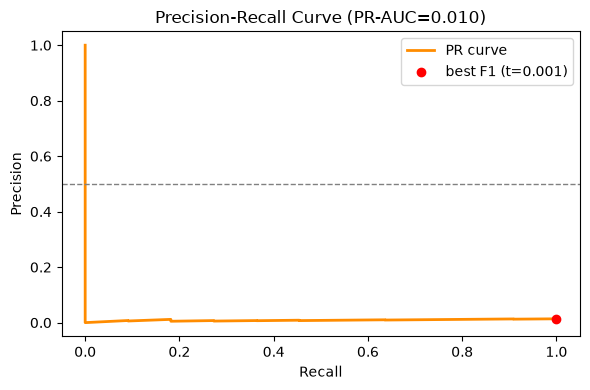

PR-AUC=0.0101  ROC-AUC=0.3152  F1=0.0000  Precision=0.0000  Recall=0.0000
Best F1 threshold=0.0007  Recall@precision=0.50=0.0000
[grouped | a: base] features=87 CV PR-AUC 0.6202+-0.0959 test PR-AUC 0.0101


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

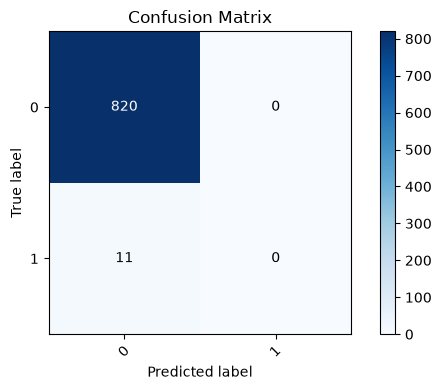


Accuracy: 98.68% 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       820
           1       0.00      0.00      0.00        11

    accuracy                           0.99       831
   macro avg       0.49      0.50      0.50       831
weighted avg       0.97      0.99      0.98       831



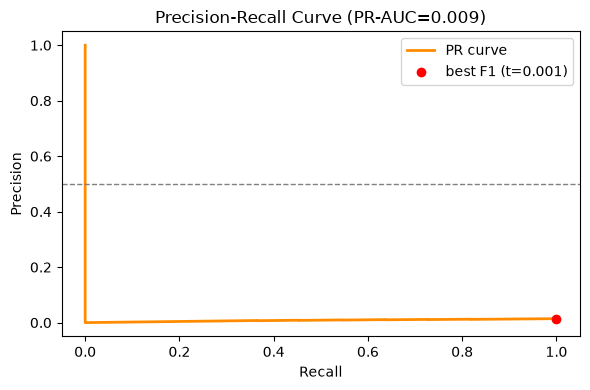

PR-AUC=0.0091  ROC-AUC=0.2543  F1=0.0000  Precision=0.0000  Recall=0.0000
Best F1 threshold=0.0006  Recall@precision=0.50=0.0000
[grouped | b: base + client] features=116 CV PR-AUC 0.7277+-0.0599 test PR-AUC 0.0091


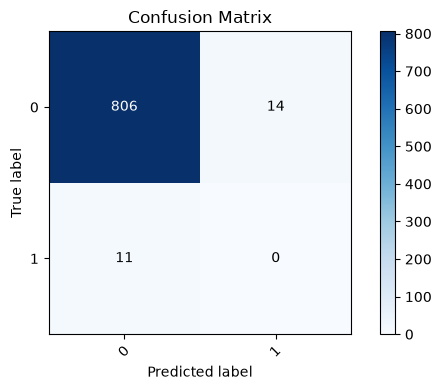


Accuracy: 96.99% 

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       820
           1       0.00      0.00      0.00        11

    accuracy                           0.97       831
   macro avg       0.49      0.49      0.49       831
weighted avg       0.97      0.97      0.97       831



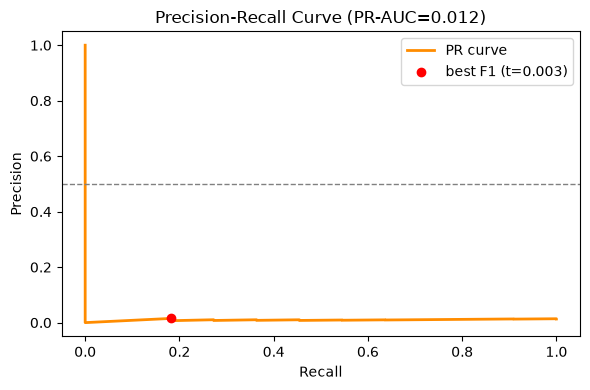

PR-AUC=0.0119  ROC-AUC=0.3670  F1=0.0000  Precision=0.0000  Recall=0.0000
Best F1 threshold=0.0031  Recall@precision=0.50=0.0000
[grouped | c: base + SCE] features=431 CV PR-AUC 0.4532+-0.1693 test PR-AUC 0.0119


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:309: FutureWarning: The provided callable <function std at 0x000001D47F599260> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  .agg(


C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:362: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(prob=lambda x: x["n"] / x.groupby("value")["n"].transform("sum"))
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:368: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current be

C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:309: FutureWarning: The provided callable <function std at 0x000001D47F599260> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  .agg(
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:267: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["value", "fraud_flag"])["value"]
C:\Users\mateu\Documents\GitHub\la-wt\Fraud-Prediction\foc-177-f2\src\funs.py:270: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sile

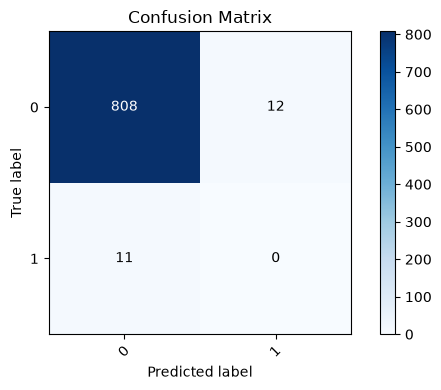


Accuracy: 97.23% 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       820
           1       0.00      0.00      0.00        11

    accuracy                           0.97       831
   macro avg       0.49      0.49      0.49       831
weighted avg       0.97      0.97      0.97       831



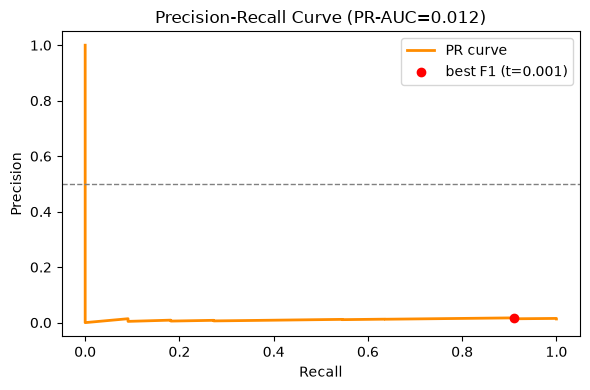

PR-AUC=0.0123  ROC-AUC=0.4338  F1=0.0000  Precision=0.0000  Recall=0.0000
Best F1 threshold=0.0013  Recall@precision=0.50=0.0000
[grouped | d: base + dictionary] features=94 CV PR-AUC 0.4786+-0.1349 test PR-AUC 0.0123

identity check: PASS — all arms ran on identical row splits


In [7]:
X_ref = enriched[["customer"]]

X_tr, X_te, _, _ = chronological_split(
    X_ref, y_full, timestamp=enriched["timestamp"], test_size=0.2, random_state=42
)
chron_train_idx, chron_test_idx = X_tr.index, X_te.index

X_tr, X_te, _, _ = grouped_split(
    X_ref, y_full, enriched["customer"], timestamp=enriched["timestamp"], test_size=0.2, random_state=42
)
grp_train_idx, grp_test_idx = X_tr.index, X_te.index

assert not (set(chron_train_idx) & set(chron_test_idx)), "chronological split overlaps"
assert not (set(grp_train_idx) & set(grp_test_idx)), "grouped split overlaps"
assert set(enriched.loc[grp_train_idx, "customer"]).isdisjoint(
    enriched.loc[grp_test_idx, "customer"]
), "grouped split shares customers"
assert len(chron_test_idx) == int(np.ceil(len(enriched) * 0.2)), (
    "chronological test rows != ceil(20% of all rows)"
)
assert len(chron_train_idx) + len(chron_test_idx) == len(enriched), (
    "chronological split lost rows"
)
# grouped_split guarantees CUSTOMER disjointness and hands the last ceil(20%)
# of customers (by first-seen transaction) to the test set — so the size assert
# reads customers, not rows (a customer contributes ~10 rows on average;
# comparing grp_test_idx length to 20 was the bug fixed here).
assert (
    enriched.loc[grp_test_idx, "customer"].nunique()
    == int(np.ceil(enriched["customer"].nunique() * 0.2))
), "grouped test set is not the last ceil(20%) of customers"
assert len(grp_train_idx) + len(grp_test_idx) == len(enriched), (
    "grouped split lost rows"
)
print(
    "chronological split: %d train / %d test rows | grouped split: %d train / %d test rows, %d/%d/%d customers (train/test/total)"
    % (
        len(chron_train_idx), len(chron_test_idx),
        len(grp_train_idx), len(grp_test_idx),
        enriched.loc[grp_train_idx, "customer"].nunique(),
        enriched.loc[grp_test_idx, "customer"].nunique(),
        enriched["customer"].nunique(),
    )
)


def run_split(split_name, train_idx, test_idx):
    # One split, all four arms; identical-splits guard per arm (nb7 discipline).
    rows = []
    for label, arm_fn in ARMS:
        row, used_train, used_test = arm_fn(train_idx, test_idx)
        assert used_train.equals(train_idx) and used_test.equals(test_idx), (
            "split drift between arms in %s (%s)" % (split_name, label)
        )
        row["split"] = split_name
        row["arm"] = label
        rows.append(row)
        print(
            "[%s | %s] features=%d CV PR-AUC %.4f+-%.4f test PR-AUC %.4f"
            % (
                split_name, label, row["encoded features"],
                row["CV PR-AUC mean"], row["CV PR-AUC std"], row["test PR-AUC"],
            )
        )
    return rows


# Chance levels for the report: a random ranking lands at the test
# positive rate on PR-AUC. Both test sets are small in positives, so the
# exact counts are printed next to the numbers they contextualize.
chron_pos = int(y_full.loc[chron_test_idx].sum())
grp_pos = int(y_full.loc[grp_test_idx].sum())
print(
    "chronological test positives: %d of %d rows (chance PR-AUC %.4f)"
    % (chron_pos, len(chron_test_idx), chron_pos / len(chron_test_idx))
)
print(
    "grouped test positives: %d of %d rows (chance PR-AUC %.4f)"
    % (grp_pos, len(grp_test_idx), grp_pos / len(grp_test_idx))
)

results_rows = run_split("chronological", chron_train_idx, chron_test_idx)
results_rows += run_split("grouped", grp_train_idx, grp_test_idx)
print("\nidentity check: PASS — all arms ran on identical row splits")

In [8]:
RESULT_COLS = [
    "split",
    "arm",
    "test PR-AUC",
    "test ROC-AUC",
    "test F1 (frozen threshold)",
    "test recall@precision=0.50",
    "CV PR-AUC mean",
    "CV PR-AUC std",
    "frozen threshold",
    "encoded features",
]
results = pd.DataFrame(results_rows)[RESULT_COLS]
print(results.round(4).to_string(index=False))

# Per-split verdict (nb7's plain-words style): does SCE move the base, and does
# it beat the nb5-style dictionary arm under the identical protocol?
EPSILON = 0.001
for split_name in results["split"].unique():
    block = results[results["split"] == split_name].set_index("arm")
    sce_delta = (
        block.loc["c: base + SCE", "test PR-AUC"]
        - block.loc["a: base", "test PR-AUC"]
    )
    dict_delta = (
        block.loc["c: base + SCE", "test PR-AUC"]
        - block.loc["d: base + dictionary", "test PR-AUC"]
    )
    print(
        "\n%s split: SCE vs base %+.4f | SCE vs dictionary %+.4f -> %s"
        % (
            split_name, sce_delta, dict_delta,
            "SCE MOVES the baseline" if abs(sce_delta) > EPSILON else "NO SIGNAL from SCE",
        )
    )

wide = results.pivot(
    index="arm", columns="split", values=["test PR-AUC", "test F1 (frozen threshold)"]
)
print("\nwide view (for the report):")
print(wide.round(4).to_string())

results

        split                  arm  test PR-AUC  test ROC-AUC  test F1 (frozen threshold)  test recall@precision=0.50  CV PR-AUC mean  CV PR-AUC std  frozen threshold  encoded features
chronological              a: base       0.0532        0.6361                      0.0000                      0.0417          0.4633         0.0660            0.9652                87
chronological     b: base + client       0.2374        0.7692                      0.2667                      0.2083          0.5227         0.0809            0.6648               116
chronological        c: base + SCE       0.0340        0.5542                      0.0000                      0.0000          0.2214         0.1415            0.1627               429
chronological d: base + dictionary       0.1034        0.7653                      0.0769                      0.0417          0.3539         0.0814            0.9107                92
      grouped              a: base       0.0101        0.3152              

,split,arm,test PR-AUC,test ROC-AUC,test F1 (frozen threshold),test recall@precision=0.50,CV PR-AUC mean,CV PR-AUC std,frozen threshold,encoded features
0,chronological,a: base,0.053161,0.636130,0.000000,0.041667,0.463281,0.066016,0.965222,87
1,chronological,b: base + client,0.237362,0.769246,0.266667,0.208333,0.522684,0.080902,0.664849,116
2,chronological,c: base + SCE,0.033955,0.554203,0.000000,0.000000,0.221445,0.141529,0.162695,429
3,chronological,d: base + dictionary,0.103426,0.765349,0.076923,0.041667,0.353888,0.081442,0.910705,92
4,grouped,a: base,0.010140,0.315188,0.000000,0.000000,0.620247,0.095934,0.710688,87
5,grouped,b: base + client,0.009108,0.254324,0.000000,0.000000,0.727686,0.059880,0.895625,116
6,grouped,c: base + SCE,0.011912,0.366962,0.000000,0.000000,0.453209,0.169348,0.012351,431
7,grouped,d: base + dictionary,0.012331,0.433814,0.000000,0.000000,0.478585,0.134868,0.604654,94


### Interpretation (read after the results table)

- **Does SCE beat the dictionary signal on the chronological split?** The
  apples-to-apples comparison is arm (c) vs arm (d) *within this notebook*: both
  run under the identical frozen-threshold protocol, while nb5's published 0.507
  came from a stratified random split with a grid-searched XGB — indicative
  context, not a peer number. A null or negative (c)-vs-(d) delta on the
  chronological split is a legitimate finding: with 91 positives and
  `min_group_size=5`, most interaction-level groups back off to coarse or
  global rates, so arm (c) can carry ~340 context columns that are
  near-duplicates of the global fraud rate.
- **Does anything survive the customer-grouped split?** The grouped split
  removes shared customers, so any mechanism that works by memorizing which
  *customers* defraud should collapse toward the base arm. nb7's client lift
  (0.0532 -> 0.2374 chronological) was read as customer-identity signal; expect
  arm (b) to lose most of it here. If arm (c) keeps a residual lift on the
  grouped split, that is the only evidence in this notebook of *transferable*
  context signal; if it collapses too, every enrichment path in F1/F2 is
  identity-driven.
- **CV-vs-test gap.** `cross_validate_model` folds are stratified random within
  TRAIN, so they mix periods; the chronological test set is strictly later. nb7
  arm a showed the resulting gap (CV 0.4633 vs test 0.0532). Read the CV column
  as stability, never as the headline; a large CV-vs-test gap on arm (c) is
  expected, not a bug.
- **Known artifacts.** (1) The engine's time cross-fit leaves the earliest ~17%
  of fitting rows with NaN context features (XGB routes NaN), so arm (c) trains
  on a slightly different feature distribution than it scores against. (2) The
  dictionary arm keeps nb5's `count_filter=0`, so rare levels get extreme
  dictionary rates — nb5's construction, reproduced deliberately. (3) 91
  positives make every test metric noisy at the third decimal; deltas below
  ~0.01 PR-AUC are not interpretable. (4) nb4 (0.329) / nb5 (0.507) numbers come
  from stratified splits and a grid-searched XGB — quoted for context only.

## Summary

- F2 comparison implemented: SCE fraud-rate context enrichment vs base, client
  and nb5-style dictionary arms, each under the chronological and the
  customer-grouped split, under one frozen-threshold protocol with
  identical-splits assertions.
- The SCE engine (`cross_fit_strategy="time"`, `time_col="timestamp"`) was
  verified empirically: out-of-fold context features do not respond to future
  targets (with a moving control), and unseen groups at `transform()` back off
  to the global rate without error.
- The engine is refit inside every CV fold (and inside the validation carve)
  through sklearn-compatible wrappers, so no fold or split is scored with
  statistics built on its own targets.
- The verdict for the F2 question is read from the results table above; the
  interpretation cell lists the standing caveats for quoting it.

**Engine dtype note.** stat-context 0.4.0 string-casts converted-dtype grouping columns during out-of-fold assignment (int `hour` -> str `hour`, Interval `amount_eur_bucket` -> str), which would fragment groups and duplicate dummy names downstream. All grouping columns are normalized to str before the engine runs, so group keys stay exact and one-hot encoding stays unique.
